# Delamanid stable graphs

Stability selection results for CMM-logistic on TB delamanid data (lineage-stratified). Loads `results/tb_subsample_dlm_lineage_*/edge_stability.csv` and visualizes the stable BN at conventional and conservative thresholds.

In [7]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parents[2]))
sys.path.insert(0, str(Path.cwd().parents[2] / 'external' / 'cmm'))

import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

import pandas as pd
from src_tb.causal_recovery.cmm_utils import visualize_stable_bn

RESULTS = Path.cwd().parents[2] / 'results' / 'tb_subsample_dlm_lineage_20260508_0047'
df = pd.read_csv(RESULTS / 'edge_stability.csv')
df.head()

,source,target,count,n_eligible,frequency
0,lineage_4,fgd1_Phe320Phe,97,100,0.97
1,lineage_2,mmpl5_Asp767Asn,96,100,0.96
2,lineage_4,mmpl5_Thr794Ile,96,100,0.96
3,lineage_2,rv0678_G*128C,87,100,0.87
4,rv0678_G*128C,fgd1_G*357C,75,100,0.75


## Stable graph (frequency ≥ 0.5)

Meinshausen–Bühlmann convention: edges retained more often than chance across stability-selection runs.

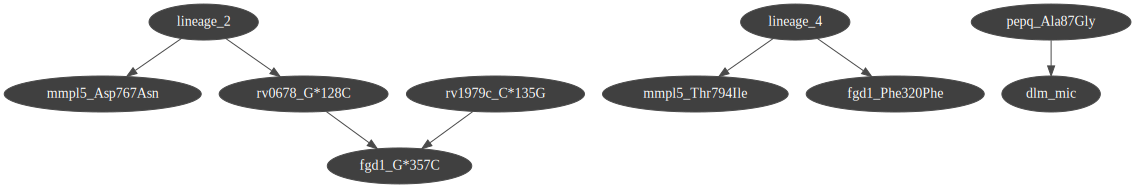

In [8]:
visualize_stable_bn(df, threshold=0.5, continuous_features=['dlm_mic'], size='20')

## Conservative cut (frequency ≥ 0.7)

Tighter threshold: structural backbone (high-confidence lineage→mutation co-occurrence and strong mutation→mutation edges).

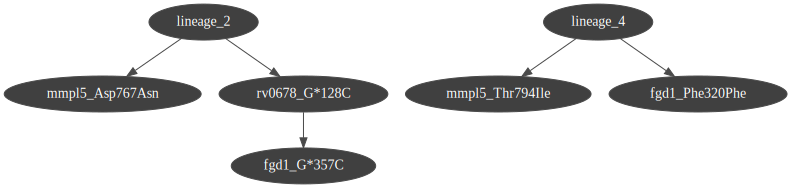

In [9]:
visualize_stable_bn(df, threshold=0.7, continuous_features=['dlm_mic'], size='20')

## Top edges

All edges with frequency ≥ 0.3, sorted by frequency. `n_eligible` is the number of subsample runs in which both endpoints were present.

In [10]:
df.sort_values('frequency', ascending=False).query('frequency >= 0.3').reset_index(drop=True)

,source,target,count,n_eligible,frequency
0,lineage_4,fgd1_Phe320Phe,97,100,0.970000
1,lineage_2,mmpl5_Asp767Asn,96,100,0.960000
2,lineage_4,mmpl5_Thr794Ile,96,100,0.960000
3,lineage_2,rv0678_G*128C,87,100,0.870000
4,rv0678_G*128C,fgd1_G*357C,75,100,0.750000
5,rv1979c_C*135G,fgd1_G*357C,54,90,0.600000
6,pepq_Ala87Gly,dlm_mic,52,100,0.520000
7,lineage_4,fgd1_G*357C,47,100,0.470000
8,lineage_4,rv1979c_C*135G,40,90,0.444444
9,lineage_2,dlm_mic,41,100,0.410000


## Direct MIC drivers

Edges with `dlm_mic` as target.

In [11]:
df[df['target'] == 'dlm_mic'].sort_values('frequency', ascending=False).reset_index(drop=True)

,source,target,count,n_eligible,frequency
0,pepq_Ala87Gly,dlm_mic,52,100,0.520000
1,lineage_2,dlm_mic,41,100,0.410000
2,rv1979c_C*135G,dlm_mic,35,90,0.388889
3,rv0678_G*128C,dlm_mic,16,100,0.160000
4,lineage_4,dlm_mic,12,100,0.120000
5,fgd1_G*357C,dlm_mic,9,100,0.090000
6,mmpl5_Asp767Asn,dlm_mic,8,100,0.080000
7,mmpl5_Thr794Ile,dlm_mic,1,100,0.010000
8,fgd1_Phe320Phe,dlm_mic,1,100,0.010000


## Per-node k summary

Best k chosen per node across stability-selection runs. Binary nodes typically pin at k=1 (no mixture structure); the continuous outcome (`dlm_mic`) is where higher k indicates non-Gaussian conditional distributions.

In [12]:
pd.read_csv(RESULTS / 'per_node_k.csv')

,feature,n_runs_present,k1_count,k2_count,k4_count,k5_count,mean_k,median_k,mode_k
0,dlm_mic,100,0,1,27,72,4.7,5.0,5
1,rv0678_G*128C,100,100,0,0,0,1.0,1.0,1
2,mmpl5_Asp767Asn,100,100,0,0,0,1.0,1.0,1
3,mmpl5_Ile948Val,100,100,0,0,0,1.0,1.0,1
4,mmpl5_Thr794Ile,100,100,0,0,0,1.0,1.0,1
5,pepq_Ala87Gly,100,100,0,0,0,1.0,1.0,1
6,rv1979c_C*135G,90,90,0,0,0,1.0,1.0,1
7,fgd1_G*357C,100,100,0,0,0,1.0,1.0,1
8,fgd1_Phe320Phe,100,100,0,0,0,1.0,1.0,1
9,lineage_2,100,100,0,0,0,1.0,1.0,1
